### Lab IV: Linear Models
### Answer all three sets of questions

---

**Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

In [52]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score

In [53]:
# load in data
df = pd.read_csv("https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv")
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [54]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22153 entries, 0 to 22152
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Price                 22153 non-null  int64  
 1   Review Scores Rating  22153 non-null  float64
 2   Neighbourhood         22153 non-null  str    
 3   Property Type         22153 non-null  str    
 4   Room Type             22153 non-null  str    
dtypes: float64(1), int64(1), str(3)
memory usage: 865.5 KB


In [55]:
df.describe()

,Price,Review Scores Rating
count,22153.000000,22153.000000
mean,154.787388,91.993093
std,148.843320,8.850658
min,10.000000,20.000000
25%,85.000000,89.000000
50%,125.000000,94.000000
75%,190.000000,100.000000
max,10000.000000,100.000000


open data wrangler and make initial observations:

- no missing data
- categorry features are neighbourhood, property type and room type
- neighbourhood 5 distinct values
- property type 18 distince values but should maybe group togther and make a bigger other category
- room type 3 distinct values
-numerica value it price which is the target and also the ratings

1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.

In [56]:
# rename the columns to shorter and correct spelling for easier refrence later
df.rename(columns={"Review Scores Rating": "Score"}, inplace=True)
df.rename(columns={"Neighbourhood ": "Neighborhood"}, inplace=True)

# group by the neighborhood and see the average prices adn review scrore ratings
avg = df.groupby('Neighborhood')[["Price", "Score"]].mean()
print(avg.sort_values(by='Price', ascending=False)) # order by the highest price

                    Price      Score
Neighborhood                        
Manhattan      183.664286  91.801496
Staten Island  146.166667  90.843750
Brooklyn       127.747378  92.363497
Queens          96.857233  91.549057
Bronx           75.276498  91.654378


the most expensive neighborhood on average is Manhatten.

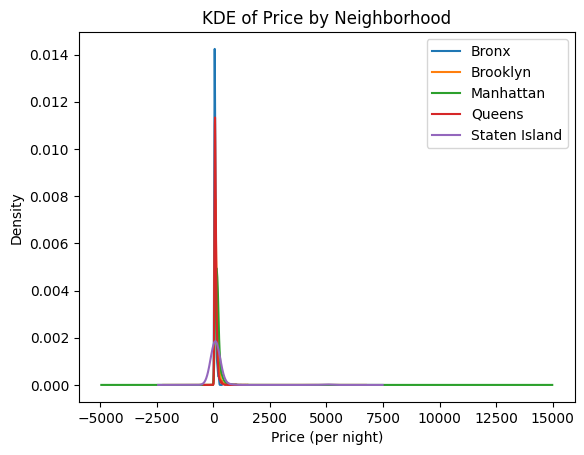

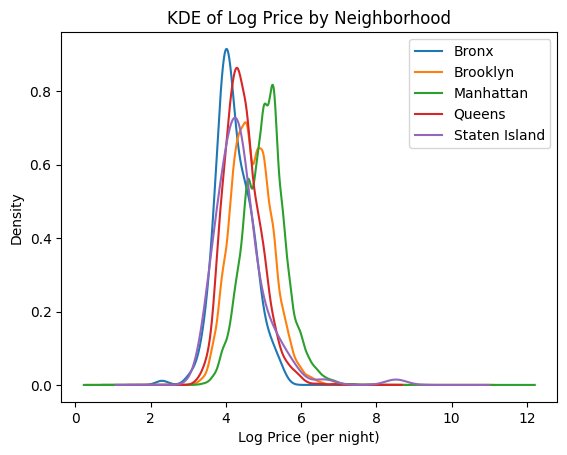

In [57]:
# KDE for price
df.groupby('Neighborhood')['Price'].plot.kde(legend=True)
plt.title('KDE of Price by Neighborhood')
plt.xlabel('Price (per night)')
plt.show()

#make new column of hte log values of price
df['log_Price'] = np.log(df['Price'])
# Kernel density plot for log Price
df.groupby('Neighborhood')['log_Price'].plot.kde(legend=True)
plt.title('KDE of Log Price by Neighborhood')
plt.xlabel('Log Price (per night)')
plt.show()

the initical price kde shoes very close and rigth skewes distribuion so when most of the data is low prices then a couple expensive ones create outliers that then pull it out. so taking the log of the price makes teh distributions more normally shaped and easier to see the differences between each borough.

2. Regress price on `Neighborhood` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?

In [58]:
#onehot encode the neighboord
#keep drop first as false since using no intercept later and can compare all 5 to previous part
q2_dummies = pd.get_dummies(df, columns=['Neighborhood'], drop_first=False, prefix='Neighborhood')

# check the new dummy column names
print(q2_dummies.columns.tolist())

['Price', 'Score', 'Property Type', 'Room Type', 'log_Price', 'Neighborhood_Bronx', 'Neighborhood_Brooklyn', 'Neighborhood_Manhattan', 'Neighborhood_Queens', 'Neighborhood_Staten Island']


In [59]:
# make the x aka features with all the neighboord boroughs
X = q2_dummies[['Neighborhood_Bronx','Neighborhood_Brooklyn', 'Neighborhood_Manhattan', 
               'Neighborhood_Queens', 'Neighborhood_Staten Island']]
#make the y aka the target price
y = q2_dummies['Price']

# run regression iwth the intercept beuacse if thers an intercept adn 
# all 5 of the dummers then there perfect correlation and multicollinearlity
# when get rid of the intercept then the dummys just the mean price of that borugh and add up to 1
model_q2 = LinearRegression(fit_intercept=False)
model_q2.fit(X, y)

# show coefficients with their column names
coef_q2 = pd.Series(model_q2.coef_, index=X.columns)
print("Coefficients w/o intercept:")
print(coef_q2)
print(f"\nR²: {model_q2.score(X, y):.4f}")

Coefficients w/o intercept:
Neighborhood_Bronx             75.276498
Neighborhood_Brooklyn         127.747378
Neighborhood_Manhattan        183.664286
Neighborhood_Queens            96.857233
Neighborhood_Staten Island    146.166667
dtype: float64

R²: 0.0463


The coefficients are bascically just the neighborhood mean prices. they match part 1 because when its regressed on a single categoy target then each coef is the group average for that category

3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?


In [60]:
# this time need to drop the first one since there is going to be an intercept.
#this will make the bronz macscailly the base or starting point but can still 
# calcutated by setting everythign else to zero
q3_dummies = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True, prefix='Neighborhood')
print(q3_dummies.columns.tolist())

['Price', 'Score', 'Property Type', 'Room Type', 'log_Price', 'Neighborhood_Brooklyn', 'Neighborhood_Manhattan', 'Neighborhood_Queens', 'Neighborhood_Staten Island']


In [61]:
#make features but without the bronz since its dropped
X = q3_dummies[['Neighborhood_Brooklyn', 'Neighborhood_Manhattan',
                 'Neighborhood_Queens', 'Neighborhood_Staten Island']]
y = q3_dummies['Price']

# with intercept
model_q3 = LinearRegression(fit_intercept=True)
model_q3.fit(X, y)

print(f"Intercept: {model_q3.intercept_:.2f}")
coef_q3 = pd.Series(model_q3.coef_, index=X.columns)
print("Coefficients w/ intercept:")
print(coef_q3)
print(f"\nR²: {model_q3.score(X, y):.4f}")

Intercept: 75.28
Coefficients w/ intercept:
Neighborhood_Brooklyn          52.470881
Neighborhood_Manhattan        108.387789
Neighborhood_Queens            21.580735
Neighborhood_Staten Island     70.890169
dtype: float64

R²: 0.0463


the intercept is actually going to be the mean of the Bronx price because that is the value when all other variables are 0. Since I one-hot encoded with drop_first=True, this basically sets the Bronx as the baseline, where all other coefficients are measured relative to it as the starting point. So if we set all of those to zero, aka look at the y-intercept where x is zero, we get the mean price of the Bronx.

to get the coeficients that u just add the value of the intercept to each one since they are just the differece from teh base. for example we know that the bronz avg aka intercept is about 75.3 so adding that to the brooklyn 52.5 will get you ~127 which mathces the results from part 1 and 2


4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [62]:
# onehot encode Neighborhood
# drop_first=True because gonna use an intercept
# This drops Bronx
q4_dummies = pd.get_dummies(df, columns=['Neighborhood'], drop_first=True, prefix=['Neighborhood'])

# make X by taking Score plus all neighborhood dummies
# used this list comprehension to automatically grab all dummy columns by prefix instead of 
#manurally putting in all individual column names
neighborhood_cols = [col for col in q4_dummies.columns if col.startswith('Neighborhood_')]

X = q4_dummies[['Score'] + neighborhood_cols]
y = q4_dummies['Price']

# do 80/20 train/test split with random_state=42
# random_state ensures that u get the same split every time code runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [63]:
# fit the model on training data only
model_q4 = LinearRegression()
model_q4.fit(X_train, y_train)

# make predictions on the test set
y_pred_q4 = model_q4.predict(X_test)

# evaluate performance on the test set
r2_q4   = r2_score(y_test, y_pred_q4)
rmse_q4 = np.sqrt(mean_squared_error(y_test, y_pred_q4))

print(f"Test R²: {r2_q4:.4f}")
print(f"Test RMSE: {rmse_q4:.2f}")
coef_q4 = pd.Series(model_q4.coef_, index=X.columns)
print("Coefficients:")
print(coef_q4.sort_values(ascending=False))

Test R²: 0.0459
Test RMSE: 140.92
Coefficients:
Neighborhood_Manhattan        107.413553
Neighborhood_Brooklyn          51.555970
Neighborhood_Staten Island     23.454672
Neighborhood_Queens            20.198573
Score                           1.211852
dtype: float64


very low r^2 value so this is not really the best fit or reprenstiaton to predict accuretly for this data. its saying that each price will be about $140 more or less then the predicted values which can be a lerge change in price for one night. this is not very good at predicting. the coef of the score rating is how much the predicted price will change when the score is increaed by 1. the most expesnive proterty type is teh one with the highest coef and it looks like the most expensitve protoety type will be in manhatten cbeuasse it had the highest value at 107

5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

In [64]:
# onehot encode both Neighborhood and Property Type
# drop_first=True for both because gonna use an intercept
# This drops Bronx and Apartment
q5_dummies = pd.get_dummies(df, columns=['Neighborhood', 'Property Type'],
                             drop_first=True,
                             prefix=['Neighborhood', 'PropertyType'])

# make X by taking Score plus all neighborhood and property type dummies
# used this list comprehension to automatically grab all dummy columns by prefix instead of 
#manurally putting in all individual column names
neighborhood_cols = [col for col in q5_dummies.columns if col.startswith('Neighborhood_')]
property_cols = [col for col in q5_dummies.columns if col.startswith('PropertyType_')]

X = q5_dummies[['Score'] + neighborhood_cols + property_cols]
y = q5_dummies['Price']

# do 80/20 train/test split with random_state=42
# random_state ensures that u get the same split every time code runs
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [65]:
# fit the model on training data only
model_q5 = LinearRegression()
model_q5.fit(X_train, y_train)

# make predictions on the test set
y_pred_q5 = model_q5.predict(X_test)

# evaluate performance on the test set
r2_q5   = r2_score(y_test, y_pred_q4)
rmse_q5 = np.sqrt(mean_squared_error(y_test, y_pred_q4))

print(f"Test R²: {r2_q5:.4f}")
print(f"Test RMSE: {rmse_q5:.2f}")
print(f"\nCoefficient on Score: {model_q5.coef_[0]:.4f}")
# Score is the first column in X, so coef_[0] gives its coef

Test R²: 0.0459
Test RMSE: 140.92

Coefficient on Score: 1.2010


In [66]:
coefs_q5 = pd.Series(model_q5.coef_, index=X.columns)
print("Most epxpensive:")
print(coefs_q5.sort_values(ascending=False))


Most epxpensive:
Neighborhood_Manhattan          121.005520
PropertyType_Bungalow            83.972440
PropertyType_Loft                69.891025
PropertyType_Condominium         61.907162
Neighborhood_Brooklyn            59.633702
PropertyType_Other               49.249761
PropertyType_Boat                47.070419
PropertyType_Townhouse           44.110768
PropertyType_House               34.711346
PropertyType_Villa               33.901468
Neighborhood_Queens              26.830617
Neighborhood_Staten Island       15.700974
PropertyType_Cabin               12.389621
PropertyType_Treehouse           10.325182
Score                             1.201011
PropertyType_Camper/RV          -13.817125
PropertyType_Bed & Breakfast    -28.703920
PropertyType_Chalet             -30.237720
PropertyType_Castle             -41.810548
PropertyType_Dorm               -42.277758
PropertyType_Lighthouse         -91.438731
PropertyType_Hut               -134.604484
dtype: float64


the most epensive prperty type is the Bungalow at 83.972440


6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.

The coefficient on Review Scores Rating changes because when you add more features like Property Type in part 5, the model now has more context to work with. In multiple regression, each coefficient is estimated holding all other variables constant, so in part 4 the score coefficient was kind of doing extra work picking up variation that actually belongs to property type. Once you add those in part 5, the effect of score on price gets estimated more cleanly since the other variables are now accounting for their own share of the variation.

7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?